In [1]:
import os
from scipy import stats
import sqlalchemy
import numpy as np
from imblearn.over_sampling import SMOTE
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
caminho = os.path.abspath('../../../../data')

In [3]:

engine = sqlalchemy.create_engine("sqlite:///" + os.path.join(caminho, 'booking_db.sqlite'))

In [4]:
# tabela ABT para todas as analises
abt = pd.read_sql_table('tb_abt_churn', engine)


df_oot = abt[abt['ref_date'] == abt['ref_date'].max()].copy() # filtrando base out of time

df_abt = abt[abt['ref_date'] < abt['ref_date'].max()].copy() # filtrando base ABT

In [5]:
df_abt.head()

,ref_date,review_date,review_id,user_id,hotel_name,city,country,ultima_review,freq_total_reviews,freq_reviews_ultimos_90_dias,...,div_hoteis_diferentes,div_cidades_diferentes,div_media_estrelas_hoteis,media_custo_beneficio,temp_dias_desde_primeira_review,user_gender,age_group,traveller_type,review_text,target_churn
0,2020-12-31,2020-03-24,2,432,Kyo-to Grand,Tokyo,Japan,131.0,6,0,...,6,6,5.0,8.6000,282.0,Female,35-44,Couple,Fly long television early south range. Join le...,0
1,2020-12-31,2020-05-15,11,71,The Gateway Royale,Mumbai,India,23.0,7,1,...,6,6,5.0,8.7000,230.0,Male,25-34,Couple,Very buy everything claim government. Agree no...,0
2,2020-12-31,2020-02-28,64,37,The Bosphorus Inn,Istanbul,Turkey,26.0,6,3,...,4,4,5.0,8.5500,307.0,Male,18-24,Couple,Traditional everybody though store deal. Ball ...,0
3,2020-12-31,2020-03-23,98,1560,The Royal Compass,London,United Kingdom,24.0,5,1,...,3,3,5.0,8.1000,283.0,Female,25-34,Business,Nor poor major that. You institution board doo...,0
4,2020-12-31,2020-06-04,116,1746,The Gateway Royale,Mumbai,India,63.0,8,2,...,7,7,5.0,8.4125,210.0,Male,25-34,Business,Relationship amount as plan culture stage. Tra...,0


In [6]:
df_abt.drop(['ref_date', 'review_id', 'user_id'],axis=1, inplace=True )

In [7]:
df_abt.info()

<class 'pandas.DataFrame'>
RangeIndex: 9866 entries, 0 to 9865
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   review_date                      9866 non-null   str    
 1   hotel_name                       9866 non-null   str    
 2   city                             9866 non-null   str    
 3   country                          9866 non-null   str    
 4   ultima_review                    9866 non-null   float64
 5   freq_total_reviews               9866 non-null   int64  
 6   freq_reviews_ultimos_90_dias     9866 non-null   int64  
 7   freq_reviews_ultimos_180_dias    9866 non-null   int64  
 8   freq_reviews_ultimos_365_dias    9866 non-null   int64  
 9   sat_media_score_overall          9866 non-null   float64
 10  sat_media_score_limpeza          9866 non-null   float64
 11  sat_media_score_conforto         9866 non-null   float64
 12  sat_media_score_comodidades    

In [8]:
df_abt.isnull().sum()

review_date                          0
hotel_name                           0
city                                 0
country                              0
ultima_review                        0
freq_total_reviews                   0
freq_reviews_ultimos_90_dias         0
freq_reviews_ultimos_180_dias        0
freq_reviews_ultimos_365_dias        0
sat_media_score_overall              0
sat_media_score_limpeza              0
sat_media_score_conforto             0
sat_media_score_comodidades          0
div_hoteis_diferentes                0
div_cidades_diferentes               0
div_media_estrelas_hoteis            0
media_custo_beneficio                0
temp_dias_desde_primeira_review      0
user_gender                          0
age_group                            0
traveller_type                       0
review_text                        132
target_churn                         0
dtype: int64

In [9]:
df_abt.describe()

,ultima_review,freq_total_reviews,freq_reviews_ultimos_90_dias,freq_reviews_ultimos_180_dias,freq_reviews_ultimos_365_dias,sat_media_score_overall,sat_media_score_limpeza,sat_media_score_conforto,sat_media_score_comodidades,div_hoteis_diferentes,div_cidades_diferentes,div_media_estrelas_hoteis,media_custo_beneficio,temp_dias_desde_primeira_review,target_churn
count,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.0,9866.000000,9866.000000,9866.000000
mean,93.396817,4.215082,0.775492,2.006284,4.215082,8.944316,9.055675,9.026615,8.741970,3.891040,3.891040,5.0,8.512197,276.059193,0.013379
std,72.125184,1.983244,0.871449,1.391510,1.983244,0.120466,0.423489,0.321700,0.407300,1.751977,1.751977,0.0,0.142856,69.407174,0.114898
min,1.000000,1.000000,0.000000,0.000000,1.000000,8.300000,7.700000,8.000000,7.600000,1.000000,1.000000,5.0,7.900000,1.000000,0.000000
25%,31.000000,3.000000,0.000000,1.000000,3.000000,8.866667,8.680000,8.775000,8.400000,3.000000,3.000000,5.0,8.425000,237.000000,0.000000
50%,81.000000,4.000000,1.000000,2.000000,4.000000,8.950000,9.200000,9.000000,8.700000,4.000000,4.000000,5.0,8.520000,290.000000,0.000000
75%,139.000000,5.000000,1.000000,3.000000,5.000000,9.025000,9.400000,9.288542,9.066667,5.000000,5.000000,5.0,8.600000,331.000000,0.000000
max,365.000000,17.000000,6.000000,8.000000,17.000000,9.500000,10.000000,10.000000,10.000000,12.000000,12.000000,5.0,8.900000,365.000000,1.000000


In [10]:
# Separando as variáveis categóricas
variaveis_categoricas = []
for i in df_abt.columns[0:22].tolist():
        if df_abt.dtypes[i] == 'object' or df_abt.dtypes[i] == 'str':
            variaveis_categoricas.append(i)

In [11]:
variaveis_numericas = list(set(df_abt.columns) - set(variaveis_categoricas))

In [12]:
target = 'target_churn'
resultados = []


# VARIÁVEIS NUMÉRICAS (Teste U de Mann-Whitney)

for col in variaveis_numericas:
    # Separamos os dois grupos baseados no Churn (0 ou 1)
    grupo_0 = df_abt[df_abt[target] == 0][col].dropna()
    grupo_1 = df_abt[df_abt[target] == 1][col].dropna()
    
    # Garantimos que ambos os grupos possuem dados para testar
    if len(grupo_0) > 0 and len(grupo_1) > 0:
        # Aplicamos o teste não-paramétrico de Mann-Whitney
        stat, p_val = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
        
        # Guardamos o resultado
        resultados.append({
            'Variavel': col,
            'Tipo': 'Numérica',
            'Teste Aplicado': 'Mann-Whitney U',
            'P-Valor': p_val,
            'Significativo (95%)': 'Sim' if p_val < 0.05 else 'Não'
        })


# VARIÁVEIS CATEGÓRICAS (Teste Qui-Quadrado)

for col in variaveis_categoricas:
    # Criamos a tabela de contingência cruzando a categoria com o Churn
    tabela_contingencia = pd.crosstab(df_abt[col], df_abt[target])
    
    # O teste exige que a tabela não esteja vazia
    if not tabela_contingencia.empty:
        # Aplicamos o teste Qui-Quadrado
        chi2, p_val, dof, expected = stats.chi2_contingency(tabela_contingencia)
        
        # Guardamos o resultado
        resultados.append({
            'Variavel': col,
            'Tipo': 'Categórica',
            'Teste Aplicado': 'Qui-Quadrado',
            'P-Valor': p_val,
            'Significativo (95%)': 'Sim' if p_val < 0.05 else 'Não'
        })


# CRIAÇÃO DO RELATÓRIO FINAL

df_relatorio = pd.DataFrame(resultados)

# Ordena deixando as variáveis mais importantes (menor p-valor) no topo
df_relatorio = df_relatorio.sort_values(by='P-Valor').reset_index(drop=True)

# Exibe a tabela final completa
print(df_relatorio)



                           Variavel        Tipo  Teste Aplicado   P-Valor  \
0                      target_churn    Numérica  Mann-Whitney U  0.000000   
1           sat_media_score_overall    Numérica  Mann-Whitney U  0.025556   
2       sat_media_score_comodidades    Numérica  Mann-Whitney U  0.125148   
3                     ultima_review    Numérica  Mann-Whitney U  0.224713   
4                       user_gender  Categórica    Qui-Quadrado  0.270720   
5     freq_reviews_ultimos_365_dias    Numérica  Mann-Whitney U  0.272081   
6                freq_total_reviews    Numérica  Mann-Whitney U  0.272081   
7     freq_reviews_ultimos_180_dias    Numérica  Mann-Whitney U  0.373057   
8             media_custo_beneficio    Numérica  Mann-Whitney U  0.383741   
9             div_hoteis_diferentes    Numérica  Mann-Whitney U  0.400602   
10           div_cidades_diferentes    Numérica  Mann-Whitney U  0.400602   
11  temp_dias_desde_primeira_review    Numérica  Mann-Whitney U  0.407327   

In [13]:
# Baixa o dicionário de regras do VADER (focado em avaliações/sentimentos)
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()


# 1. Tratamento dos nulos
df_abt['review_text'] = df_abt['review_text'].fillna("")

# TRATAMENTO E EXTRAÇÃO DE SENTIMENTO
def extrair_sentimento(texto):
    if str(texto).strip() == "":
        return 0.0 # Texto vazio recebe score neutro
    
    scores = sia.polarity_scores(str(texto))
    return scores['compound'] # Retorna a nota geral de sentimento (-1 a +1)

print("Extraindo o sentimento dos textos...")
# Aplica a função em toda a base abt
df_abt['sentimento_review'] = df_abt['review_text'].apply(extrair_sentimento)


target = 'target_churn'

# Separamos os dois grupos de churn para testar a nova variável numérica de sentimento
grupo_churn = df_abt[df_abt[target] == 1]['sentimento_review'].dropna()
grupo_fiel = df_abt[df_abt[target] == 0]['sentimento_review'].dropna()

if len(grupo_churn) > 0 and len(grupo_fiel) > 0:
    stat, p_val = stats.mannwhitneyu(grupo_churn, grupo_fiel, alternative='two-sided')
    
    print("\n================ RESULTADO ================")
    print("Nova Variável: sentimento_review")
    print("Teste Aplicado: Mann-Whitney U")
    print(f"P-Valor obtido: {p_val:.6f}")
    print(f"Significativo (95%): {'Sim' if p_val < 0.05 else 'Não'}")
    print("===========================================")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Administraor\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Extraindo o sentimento dos textos...

================ RESULTADO ================
Nova Variável: sentimento_review
Teste Aplicado: Mann-Whitney U
P-Valor obtido: 0.000000
Significativo (95%): Sim


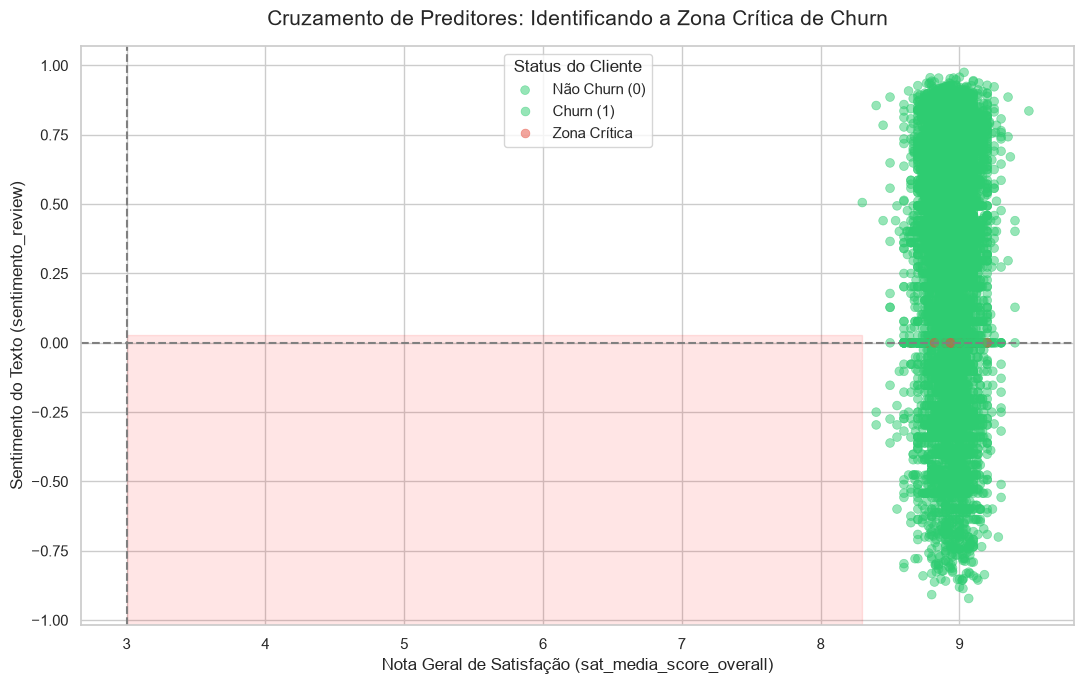

In [14]:
# Configura o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

# Criando o gráfico de dispersão
sns.scatterplot(
    data=df_abt,
    x='sat_media_score_overall',
    y='sentimento_review',
    hue='target_churn',
    palette={0: '#2ecc71', 1: '#e74c3c'}, # Verde para Não Churn, Vermelho para Churn
    alpha=0.5,                            # Transparência para ver a densidade dos pontos
    edgecolor=None,                       # Remove a borda dos pontos para suavizar
    s=40                                  # Tamanho dos pontos
)

# --- MAPEANDO A ZONA CRÍTICA (LINHAS GUIAS) ---
# Linha vertical na nota de satisfação média de corte (ex: nota 3.0)
plt.axvline(x=3.0, color='gray', linestyle='--', linewidth=1.5)

# Linha horizontal no sentimento neutro (0.0)
plt.axhline(y=0.0, color='gray', linestyle='--', linewidth=1.5)

# Adicionando um sombreamento vermelho na "Zona Crítica de Churn"
# (Canto inferior esquerdo: Satisfação < 3 e Sentimento < 0)
plt.axvspan(xmin=df_abt['sat_media_score_overall'].min(), xmax=3.0, 
            ymin=0.0, ymax=0.5, # Ajuste proporcional na escala do eixo Y (0.5 é o meio do gráfico)
            color='red', alpha=0.1, label='Zona Crítica de Churn')

# Customização de títulos e eixos
plt.title("Cruzamento de Preditores: Identificando a Zona Crítica de Churn", fontsize=15, pad=15)
plt.xlabel("Nota Geral de Satisfação (sat_media_score_overall)", fontsize=12)
plt.ylabel("Sentimento do Texto (sentimento_review)", fontsize=12)

# Ajustando as legendas
plt.legend(title="Status do Cliente", labels=["Não Churn (0)", "Churn (1)", "Zona Crítica"])

plt.tight_layout()
plt.show()


In [16]:
df_abt['target_churn'].mean()*100

np.float64(1.3379282383944862)

In [ ]:
# Filtramos o DataFrame e removemos colunas com erro (como a 'div_media_estrelas_hoteis' que deu NaN)
df_mapa = df_abt[variaveis_numericas].dropna(how='all', axis=1)

# Calculamos a matriz de correlação de Spearman
matriz_corr = df_mapa.corr(method='spearman')

#  Configura o tamanho do gráfico para ficar proporcional ao número de variáveis da sua lista
tamanho = max(11, len(variaveis_numericas) * 0.6)
plt.figure(figsize=(tamanho, tamanho * 0.8))

# Desenhamos o mapa de calor com o Seaborn
sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra os valores de correlação dentro dos quadrados
    cmap='coolwarm',     # Azul (negativo), Branco (neutro), Vermelho (positivo)
    fmt=".2f",           # Exibe com 2 casas decimais
    vmin=-1, vmax=1,     # Define os limites padrão de correlação
    linewidths=0.5,      # Linha fina de separação entre os blocos
    annot_kws={"size": 8} # Ajusta o tamanho da fonte para não cortar os números
)

plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()